Baseline Model Performance
Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1-Score: 0.9790209790209791
Confusion Matrix:
 [[41  2]
 [ 1 70]]

Best Parameters:
{'C': 0.1, 'solver': 'liblinear'}

Tuned Model Performance
Accuracy: 0.9912280701754386
Precision: 0.9861111111111112
Recall: 1.0
F1-Score: 0.993006993006993
Confusion Matrix:
 [[42  1]
 [ 0 71]]


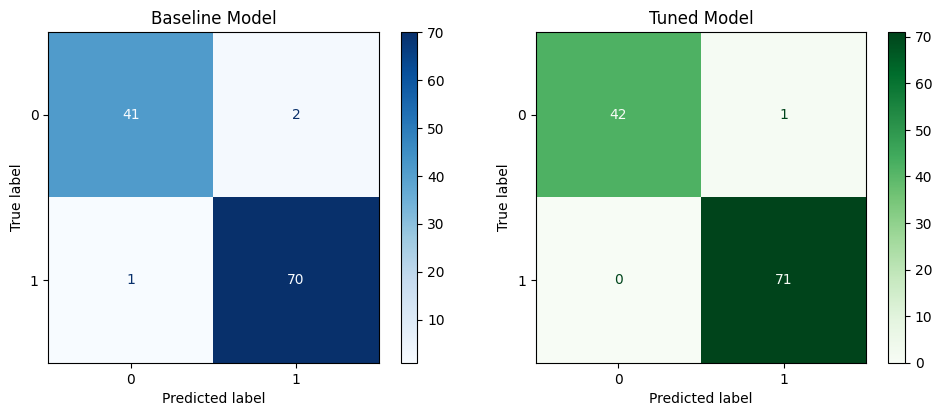

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# Load the dataset
data = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

# Features and target
X = df.drop("target", axis=1)
y = df["target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocess the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# Baseline Logistic Regression
# -------------------------
baseline_model = LogisticRegression(max_iter=10000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline Model Performance")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# -------------------------
# Hyperparameter Tuning
# -------------------------
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "solver": ["liblinear", "lbfgs"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=10000),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("\nBest Parameters:")
print(grid.best_params_)

# -------------------------
# Tuned Model Evaluation
# -------------------------
y_pred_tuned = best_model.predict(X_test)

print("\nTuned Model Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1-Score:", f1_score(y_test, y_pred_tuned))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))

# -------------------------
# Bonus: Confusion Matrix Heatmaps
# -------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], cmap="Blues"
)
axes[0].set_title("Baseline Model")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned, ax=axes[1], cmap="Greens"
)
axes[1].set_title("Tuned Model")

plt.tight_layout()
plt.show()